In [1]:
import glob
import os
from datetime import datetime

search_configs = [
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-06-10",
    #     "start": "23-53-00",
    #     "stop":  "00-00-00",
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-06-11",
    #     "start": "00-00-00",
    #     "stop":  "07-52-00",
    # },
        {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-06-11",
        "start": "10-56-00",
        "stop":  "12-33-00",
    },
]

collected_files = []

for cfg in search_configs:

    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):

        filename = os.path.basename(file_path)

        if "ECD_decay_sweep" not in filename:
            continue

        try:
            time_part = filename.split("_")[0]
            file_time = datetime.strptime(time_part, "%H-%M-%S")

            if start_time <= file_time <= stop_time:
                collected_files.append(file_path)

        except ValueError:
            continue

collected_files.sort()

print(f"Found {len(collected_files)} files")
for f in collected_files:
    print(os.path.basename(f))

Found 5 files
10-56-54_ECD_decay_sweep.hdf5
11-20-40_ECD_decay_sweep.hdf5
11-44-27_ECD_decay_sweep.hdf5
12-08-30_ECD_decay_sweep.hdf5
12-32-47_ECD_decay_sweep.hdf5


In [2]:
decay_sweep = [0.5e3, 1e3, 10e3, 20e3, 40e3] #[1e3, 10e3, 20e3, 35e3, 50e3, 70e3, 100e3, 150e3, 200e3]
decay_sweep = decay_sweep[0:len(collected_files)]
#[ 300e3, 400e3, 500e3, 600e3,  1e3, 10e3, 50e3, 100e3, 150e3, 200e3,250e3]

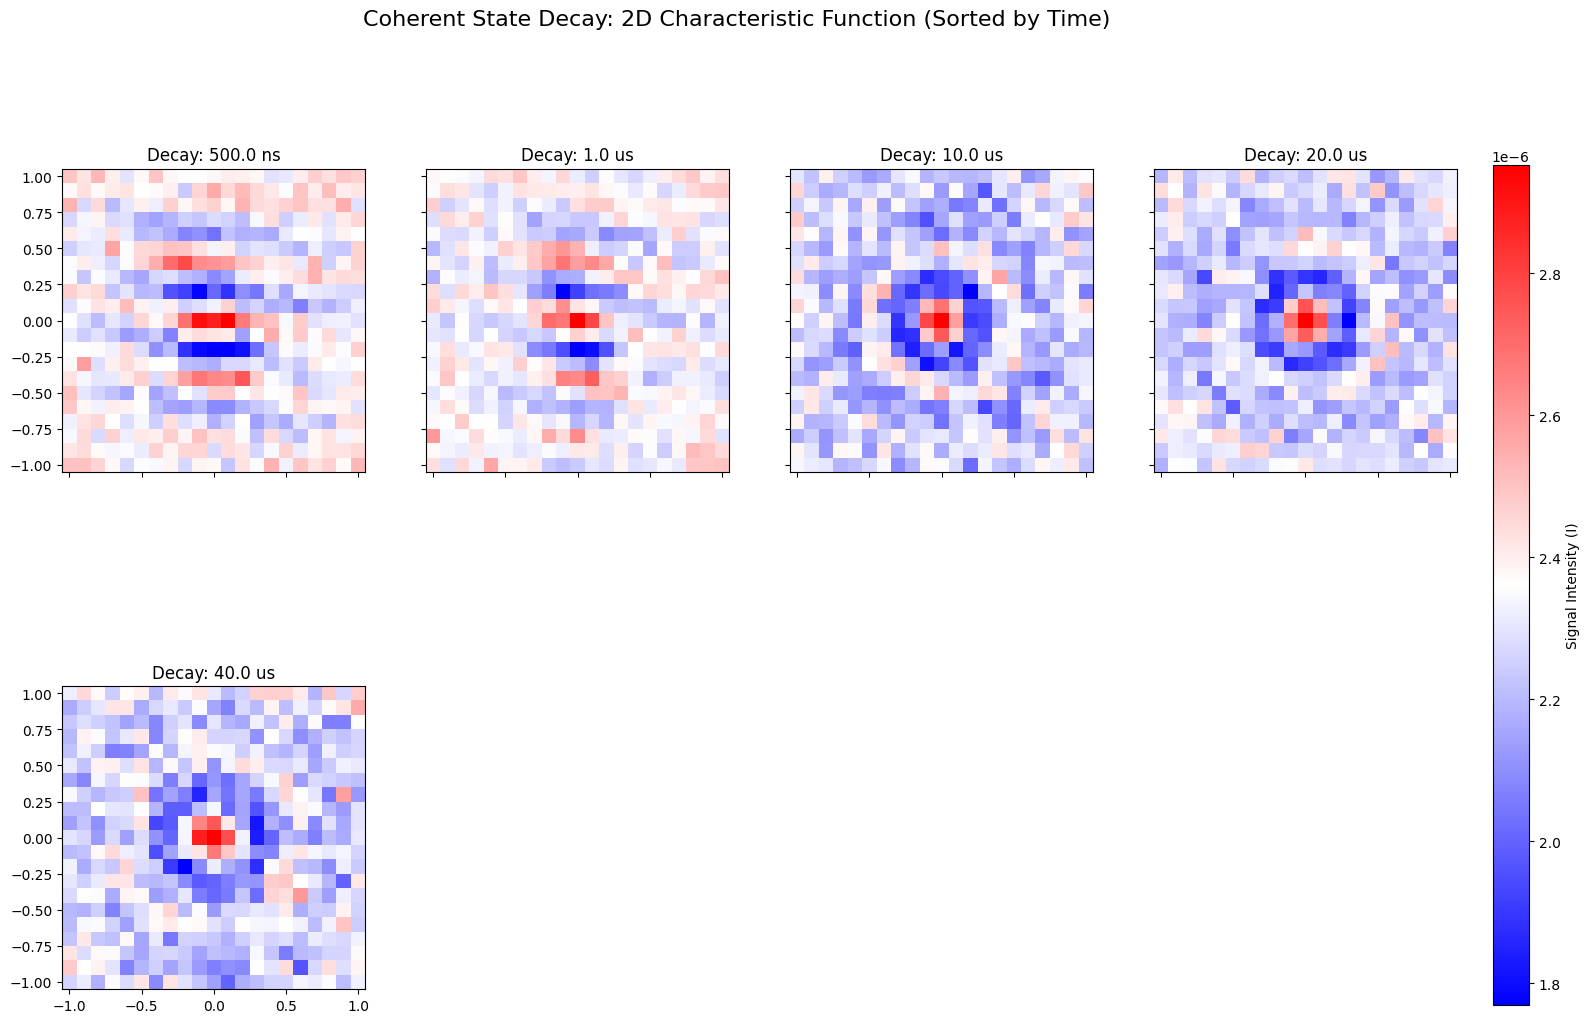

In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Map your decay sweep to your collected files
# Ensure the length of decay_sweep matches the length of collected_files
# If you ran more/fewer files, adjust the decay_sweep list accordingly.
paired_data = list(zip(decay_sweep, collected_files))

# 2. Sort the pairs by decay time (first element of the tuple)
paired_data.sort(key=lambda x: x[0])

# 3. Setup the grid (3 rows, 4 columns for 12 plots)
num_plots = min(12, len(paired_data))
cols = 4
rows = (num_plots + cols - 1) // cols  # Calculates rows needed
fig, axes = plt.subplots(rows, cols, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(num_plots):
    d_time, file_path = paired_data[i]
    
    with h5py.File(file_path, "r") as data:
        # Extract 2D data
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["ampx_x"])
        y = np.array(data["ampx_y"])
        
        # Plot using local min/max to see features or global for decay comparison
        # Using a global norm helps visualize the T1 decay contrast
        im = axes[i].pcolormesh(x, y, state, shading='auto', cmap='bwr')
        
        # Format title: Convert ns to us for readability if time is long
        time_label = f"{d_time/1e3:.1f} us" if d_time >= 1000 else f"{d_time} ns"
        axes[i].set_title(f"Decay: {time_label}")
        axes[i].set_aspect('equal')

# Clean up empty subplots if num_plots < len(axes)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a global colorbar
fig.subplots_adjust(right=0.9, top=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Signal Intensity (I)')

plt.suptitle("Coherent State Decay: 2D Characteristic Function (Sorted by Time)", fontsize=16)
plt.show()

In [4]:
## fitting

In [5]:
paired_data

[(500.0,
  'C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-11\\10-56-54_ECD_decay_sweep.hdf5'),
 (1000.0,
  'C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-11\\11-20-40_ECD_decay_sweep.hdf5'),
 (10000.0,
  'C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-11\\11-44-27_ECD_decay_sweep.hdf5'),
 (20000.0,
  'C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-11\\12-08-30_ECD_decay_sweep.hdf5'),
 (40000.0,
  'C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-11\\12-32-47_ECD_decay_sweep.hdf5')]

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-06-11\10-56-54_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 4.230428148375 B 0.4316287600515301 C 4.999999898993085 alpha 5.597477700345288 theta 0.030729226550332372


NameError: name 'LA' is not defined

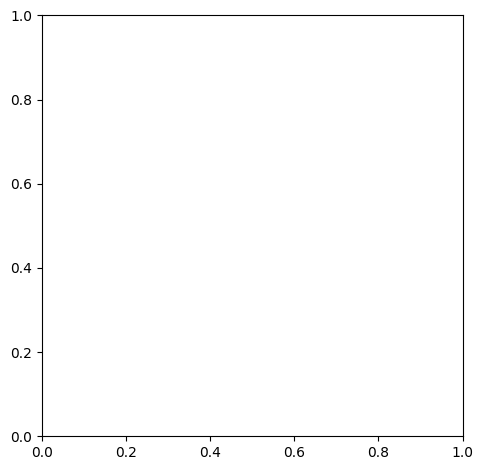

In [6]:
from re import X
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
from scipy.optimize import curve_fit


def reshape_and_avg(data_array, buffer):
    return np.average(np.reshape(data_array, buffer), axis=0)


def correct_ofs_and_amp(data_array, amp, ofs):
    return (data_array - ofs) / amp


def gaussian(x, a, b, sigma, c):
    return a * np.exp(-((x - b) ** 2) / (2 * sigma ** 2)) + c


def gaussian_fit(x, y):
    mean_arg = np.argmax(y)
    mean = x[mean_arg]
    # fit_range = int(0.2 * len(x))
    x_sample = x  # [mean_arg - fit_range : mean_arg + fit_range]
    y_sample = y  # [mean_arg - fit_range : mean_arg + fit_range]
    popt, pcov = curve_fit(
        gaussian,
        x_sample,
        y_sample,
        bounds=(
            (-np.inf, min(x_sample), -np.inf, -np.inf),
            (np.inf, max(x_sample), np.inf, np.inf),
        ),
        p0=[max(y) - min(y), 0, 0.5, max(y)],
    )
    return popt

def characteristic_coherent(xy, A, B, C, alpha, theta, S, c):
    x, y = xy[:, 0], xy[:, 1]
    # Gaussian Envelope
    envelope = np.exp(-(A * x**2 + 2 * B * x * y + C * y**2))
    # Interference term: theta is displacement angle
    # Oscillations appear along the axis defined by (y*cos - x*sin)
    oscillation = np.real(np.exp(2j * alpha * (y * np.cos(theta) - x * np.sin(theta))))
    return S * envelope * oscillation + c

tau_fit_list = []
alpha_fit_list = []
for i in range(len(paired_data)):
    char2d_filename = paired_data[i][1]
    tau = paired_data[i][0]
    print(char2d_filename)
    
    with h5py.File(char2d_filename, "r") as data:
        state_corrected = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["ampx_x"])
        y = np.array(data["ampx_y"])

        # Get fit
        x_mesh, y_mesh = np.meshgrid(x, y)
        xdata = np.transpose([x_mesh.flatten(), y_mesh.flatten()])
        ydata = np.array(state_corrected.flatten())
        print(xdata.shape,ydata.shape)
        bounds = [
        ( 0.0, -0.5, 0.0, 0, int(np.pi/180 * (-180)),-0.1, np.min(state_corrected)),
        ( 5, 0.5, 5, 6, int(np.pi/180 * (185)),0.1, np.max(state_corrected)),
        ]  # (_, A, B, C, alpha, theta)
        guess = ( 2, 0, 2, 4, np.pi/180*0,-0.01, np.mean(state_corrected) )

        popt, pcov = curve_fit(
        characteristic_coherent,
        xdata,
        ydata,
        bounds=bounds,
        p0=guess,
        )
        state_fit = characteristic_coherent(xdata, *popt).reshape(len(y), len(x))
        print("state_fit", state_fit.shape)
        # Final plot and fit
        fig, ax = plt.subplots()

        # print(popt)
        print("A",popt[0], "B",popt[1], "C",popt[2], "alpha",popt[3], "theta", popt[4])
        ax.set_aspect("equal", "box")
        fig.tight_layout()
#         sm = ax.imshow(state_fit, cmap=plt.get_cmap("coolwarm"), origin="lower")
        A, B, C = popt[:3]
        cov_matrix = np.array([[A, B], [B, C]])
        lamb1, lamb2 = LA.eig(cov_matrix)[0]
        sig1, sig2 = 1 / (2 * lamb1) ** 0.5, 1 / (2 * lamb2) ** 0.5
        print("sig1", sig1, "sig2", sig2)
        label_txt = (
        f"sig1: {sig1:.2f}, sig2: {sig2:.2f}\n|a|: {popt[3]:.3f}, theta: {popt[4]:.3f}"
        )
        print(label_txt)
        CS = ax.contour(x_mesh, y_mesh, state_fit, levels=np.linspace(np.min(state_fit),np.max(state_fit),10))
        im = ax.pcolormesh(
        x,
        y,
        state_corrected,
#         norm=colors.Normalize(vmin=-1, vmax=1),
        cmap="bwr",
        )
        plt.title(label_txt)
        print(char2d_filename)
        print("tomo_phase =  1-theta/2/np.pi = ", 1-popt[4]/2/np.pi)
        plt.show()
        alpha_fit_list.append(popt[3])        
        tau_fit_list.append(tau)

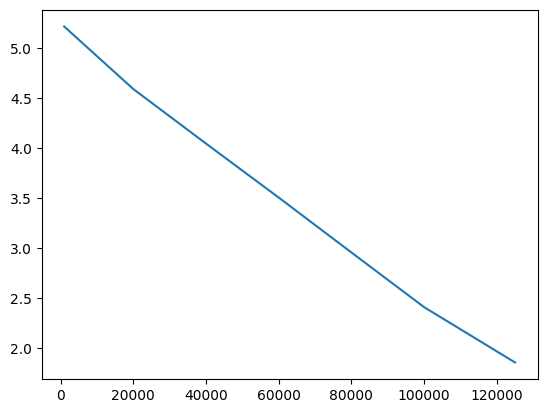

In [ ]:
plt.plot(tau_fit_list, alpha_fit_list)

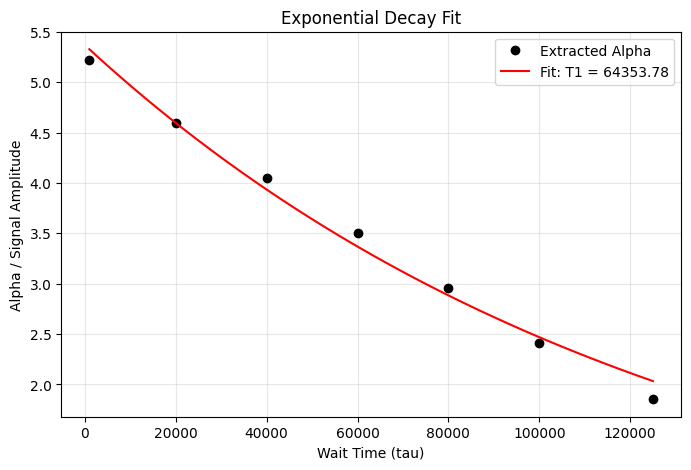

Decay Constant (T1): 64353.78ns


In [ ]:
from scipy.optimize import curve_fit

# 1. Define the exponential decay function
# t: time (tau), A: amplitude, T1: decay constant, offset: baseline
def exp_decay(t, A, T1):
    return A * np.exp(-t / (2*T1))

# 2. Prepare your data
# Ensure they are numpy arrays and in the same units (e.g., microseconds)
x_data = np.array(tau_fit_list)#[2:] 
y_data = np.array(alpha_fit_list)#[2:]

# 3. Initial Guess (Crucial for convergence)
# A: peak to peak, T1: middle of your time range, offset: last data point
guess_A = y_data[0] - y_data[-1]
guess_T1 = np.median(x_data)
p0 = [guess_A, guess_T1]

# 4. Perform the fit
try:
    popt, pcov = curve_fit(exp_decay, x_data, y_data, p0=p0)
    A_fit, T1_fit = popt
    
    # Generate smooth curve for plotting
    tau_fine = np.linspace(min(x_data), max(x_data), 100)
    alpha_smooth = exp_decay(tau_fine, *popt)

    # 5. Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(x_data, y_data, 'ko', label='Extracted Alpha')
    plt.plot(tau_fine, alpha_smooth, 'r-', label=f'Fit: T1 = {T1_fit:.2f}')
    
    plt.xlabel("Wait Time (tau)")
    plt.ylabel("Alpha / Signal Amplitude")
    plt.title("Exponential Decay Fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Decay Constant (T1): {T1_fit:.2f}ns")

except Exception as e:
    print(f"Fitting failed: {e}")

In [ ]:
# collected_files = collected_files[:-1]

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

# Use the 'collected_files' list generated from the previous script
# We'll pick a subset (e.g., 6 snapshots) to keep the plot readable
num_plots = min(12, len(collected_files))
indices = np.linspace(0, len(collected_files) - 1, num_plots, dtype=int)
#decay_sweep = [1e3, 10e3, 20e3, 35e3, 50e3, 70e3, 100e3, 150e3, 200e3]
decay_sweep = [ 300e3, 400e3, 500e3, 600e3,  1e3, 10e3, 50e3, 100e3]
fig, axes = plt.subplots(3, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, idx in enumerate(indices):
    file_path = collected_files[idx]
    with h5py.File(file_path, "r") as data:
        # Extract 2D data
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["ampx_x"])
        y = np.array(data["ampx_y"])
        
        # Get timestamp for label
        timestamp = os.path.basename(file_path).split('_')[0]
        
        # Plot
        im = axes[i].pcolormesh(x, y, state, shading='auto', cmap='bwr')
        axes[i].set_title(f"Time: {timestamp}\nDecay: {decay_sweep[idx]} ns")
        axes[i].set_aspect('equal')

# Add a global colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Signal Intensity (I)')

plt.suptitle("Coherent State Decay: 2D Characteristic Function Snapshots", fontsize=16)
plt.show()

NameError: name 'collected_files' is not defined

Processed 21-38-44_ECD_coherent_decay.hdf5: S = -1.86e-04


TypeError: Improper input: N=3 must not exceed M=1

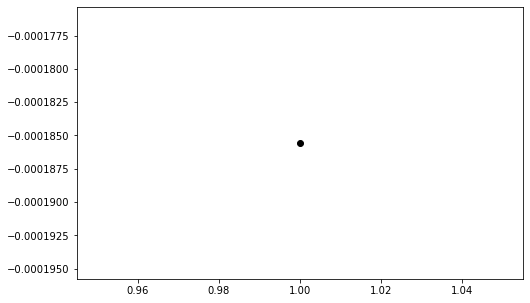

In [ ]:
import h5py
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.optimize import curve_fit

# --- 1. SETUP & FILE COLLECTION ---
data_dir = r"C:\Users\qcrew\Documents\eunice\data\2026-01-24"
cutoff_time = datetime.strptime("2026-01-24 21:26:23", "%Y-%m-%d %H:%M:%S")

# Decay times used in your sweep (ensure order matches your file generation)
decay_times = [1e3, 10e3, 20e3, 35e3, 50e3, 70e3, 100e3, 150e3, 200e3]

all_files = sorted(glob.glob(os.path.join(data_dir, "*.hdf5")))
collected_files = []

for f in all_files:
    time_part = os.path.basename(f).split('_')[0]
    file_time = datetime.strptime(f"2026-01-24 {time_part}", "%Y-%m-%d %H-%M-%S")
    if file_time > cutoff_time:
        collected_files.append(f)

# --- 2. DEFINE THE ROBUST MODEL ---
def characteristic_model(xy, A, B, C, alpha, theta, S, c):
    x, y = xy[:, 0], xy[:, 1]
    envelope = np.exp(-(A * x**2 + 2 * B * x * y + C * y**2))
    oscillation = np.imag(np.exp(2j * alpha * (y * np.cos(theta) - x * np.sin(theta))))
    return S * envelope * oscillation + c

# --- 3. BATCH PROCESSING LOOP ---
amplitudes = []
actual_decay_times = [] # To handle cases where file count != sweep length
collected_files = collected_files[:-1]
for i, file_path in enumerate(collected_files):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["ampx_x"])
        y = np.array(data["ampx_y"])
    
    x_mesh, y_mesh = np.meshgrid(x, y)
    xdata = np.c_[x_mesh.flatten(), y_mesh.flatten()]
    ydata = state.flatten()
    
    # Initial Guess logic (Crucial for small signals)
    v_range = np.max(state) - np.min(state)
    v_offset = np.mean(state)
    # p0: [A, B, C, alpha, theta, S, c]
    p0 = [0.5, 0, 0.5, 1.0, 0.0, v_range, v_offset]
    
    try:
        popt, _ = curve_fit(characteristic_model, xdata, ydata, p0=p0, maxfev=5000)
        amplitudes.append(popt[5]) # Parameter 'S'
        actual_decay_times.append(decay_times[i])
        print(f"Processed {os.path.basename(file_path)}: S = {popt[5]:.2e}")
    except Exception as e:
        print(f"Fit failed for {os.path.basename(file_path)}: {e}")

# --- 4. FINAL T1 PLOT ---
plt.figure(figsize=(8, 5))
plt.plot(np.array(actual_decay_times)/1e3, amplitudes, 'ok', label='Data')

# Optional: Fit the T1 decay (Exponential)
def t1_decay(t, amp, t1, offset):
    return amp * np.exp(-t / t1) + offset

popt_t1, _ = curve_fit(t1_decay, actual_decay_times, amplitudes, p0=[amplitudes[0], 50e3, 0])

t_fine = np.linspace(min(actual_decay_times), max(actual_decay_times), 100)
plt.plot(t_fine/1e3, t1_decay(t_fine, *popt_t1), 'r-', label=f'Fit: T1 = {popt_t1[1]/1e3:.1f} us')

plt.xlabel("Decay Time (us)")
plt.ylabel("Characteristic Function Amplitude (S)")
plt.title("Coherent State Decay ($T_1$ Measurement)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# cal_filename = "C:/Users/qcrew/Desktop/qcrew/data/somerset/20231115/175703_somerset_characteristic_function_1D_ff.h5"
# data_filename = r"C:\Users\qcrew\Documents\eunice\data\2026-01-24\20-26-03_ECD_cat.hdf5"
data_filename = r"C:\Users\qcrew\Documents\eunice\data\2026-01-24\21-38-44_ECD_coherent_decay.hdf5"


# threshold = -0.00014579810270391258




data = h5py.File(data_filename, "r")
state = np.mean(np.array(data["I"]), axis=0)  # .T # transpose to 90 degree
x = np.array(data["ampx_x"])#[:, 0])
y = np.array(data["ampx_y"])#[0, :])
# state = (np.array(data["I"]) < threshold).astype(int)
# state = state.flatten()  # revert the buffering of qcore
# file.close()

# separate internal loop into even (0.0) and odd (0.5) and state

# Get x and y sweeps for buffering and plotting
# state_corrected = correct_ofs_and_amp(state, amp, ofs)
# x = x / sig
# y = y / sig

# Get fit
x_mesh, y_mesh = np.meshgrid(x, y)


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.optimize import curve_fit
from numpy import linalg as LA

# --- 1. Revised Model Function ---
# Added 'S' for scaling and 'c' for vertical offset
def characteristic_coherent(xy, A, B, C, alpha, theta, S, c):
    x = xy[:, 0]
    y = xy[:, 1]
    envelope = np.exp(-(A * x ** 2 + 2 * B * x * y + C * y ** 2))
    oscillation = np.imag(np.exp(
        2 * 1j * y * alpha * np.cos(theta) - 2 * 1j * x * alpha * np.sin(theta)
    ))
    return S * envelope * oscillation + c

# --- 2. Data Preparation ---
# (Assuming 'state', 'x', and 'y' are defined as in your snippet)
x_mesh, y_mesh = np.meshgrid(x, y)
xdata = np.c_[x_mesh.flatten(), y_mesh.flatten()]
ydata = state.flatten()

# --- 3. Robust Fitting ---
# Bounds: [A, B, C, alpha, theta, S, c]
# We initialize S to the peak-to-peak range of your data
data_range = np.max(state) - np.min(state)
bounds = (
    [0.0, -1.0, 0.0, 0.0, 0.0, 0.0, -0.01], # Min
    [5.0,  1.0, 5.0, 10.0, 2*np.pi, 0.01, 0.01] # Max
)
guess = [0.5, 0, 0.5, 2, 0.0, data_range, np.mean(state)]

popt, pcov = curve_fit(
    characteristic_coherent,
    xdata,
    ydata,
    bounds=bounds,
    p0=guess,
)

state_fit = characteristic_coherent(xdata, *popt).reshape(len(y), len(x))

# --- 4. Plotting Original vs Fit ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Common normalization based on actual data limits
norm = colors.Normalize(vmin=np.min(state), vmax=np.max(state))

# Left: Original Data
im1 = ax1.pcolormesh(x, y, state, shading='auto', cmap='bwr', norm=norm)
ax1.set_title("Experimental ECD Data")
ax1.set_aspect("equal")

# Right: Fit + Contours
im2 = ax2.pcolormesh(x, y, state_fit, shading='auto', cmap='bwr', norm=norm)
# Auto-levels based on fit range to avoid warnings
ax2.contour(x_mesh, y_mesh, state_fit, levels=5, colors='k', linewidths=0.5, alpha=0.6)
ax2.set_title("Characteristic Function Fit")
ax2.set_aspect("equal")

# Text Info
A, B, C, alpha, theta, S, c = popt
label_txt = f"α: {alpha:.3f} | θ: {theta:.2f} rad | Scale: {S:.2e}"
fig.suptitle(label_txt)
fig.colorbar(im2, ax=[ax1, ax2], label="Signal Amplitude")

plt.show()

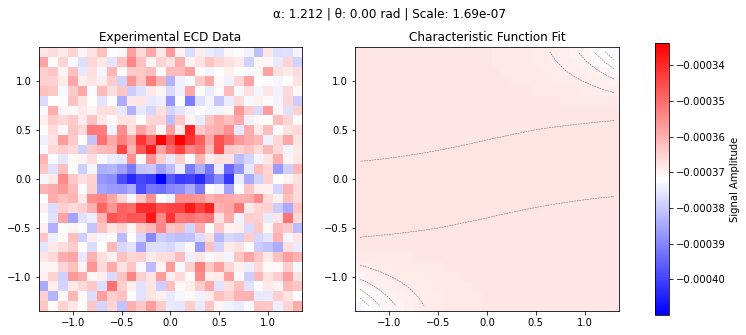

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.optimize import curve_fit
from numpy import linalg as LA

# --- 1. Revised Model Function ---
# Added 'S' for scaling and 'c' for vertical offset
def characteristic_coherent(xy, A, B, C, alpha, theta, S, c):
    x = xy[:, 0]
    y = xy[:, 1]
    envelope = np.exp(-(A * x ** 2 + 2 * B * x * y + C * y ** 2))
    oscillation = np.real(np.exp(
        2 * 1j * y * alpha * np.cos(theta) - 2 * 1j * x * alpha * np.sin(theta)
    ))
    return S * envelope * oscillation + c

# --- 2. Data Preparation ---
# (Assuming 'state', 'x', and 'y' are defined as in your snippet)
x_mesh, y_mesh = np.meshgrid(x, y)
xdata = np.c_[x_mesh.flatten(), y_mesh.flatten()]
ydata = state.flatten()

# --- 3. Robust Fitting ---
# Bounds: [A, B, C, alpha, theta, S, c]
# We initialize S to the peak-to-peak range of your data
data_range = np.max(state) - np.min(state)
bounds = (
    [0.0, -1.0, 0.0, 0.0, 0.0, 0.0, -0.01], # Min
    [5.0,  1.0, 5.0, 10.0, 2*np.pi, 0.01, 0.01] # Max
)
guess = [0.5, 0, 0.5, 2, 0.0, data_range, np.mean(state)]

popt, pcov = curve_fit(
    characteristic_coherent,
    xdata,
    ydata,
    bounds=bounds,
    p0=guess,
)

state_fit = characteristic_coherent(xdata, *popt).reshape(len(y), len(x))

# --- 4. Plotting Original vs Fit ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Common normalization based on actual data limits
norm = colors.Normalize(vmin=np.min(state), vmax=np.max(state))

# Left: Original Data
im1 = ax1.pcolormesh(x, y, state, shading='auto', cmap='bwr', norm=norm)
ax1.set_title("Experimental ECD Data")
ax1.set_aspect("equal")

# Right: Fit + Contours
im2 = ax2.pcolormesh(x, y, state_fit, shading='auto', cmap='bwr', norm=norm)
# Auto-levels based on fit range to avoid warnings
ax2.contour(x_mesh, y_mesh, state_fit, levels=5, colors='k', linewidths=0.5, alpha=0.6)
ax2.set_title("Characteristic Function Fit")
ax2.set_aspect("equal")

# Text Info
A, B, C, alpha, theta, S, c = popt
label_txt = f"α: {alpha:.3f} | θ: {theta:.2f} rad | Scale: {S:.2e}"
fig.suptitle(label_txt)
fig.colorbar(im2, ax=[ax1, ax2], label="Signal Amplitude")

plt.show()

<ipython-input-24-7f789fd15f99>:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


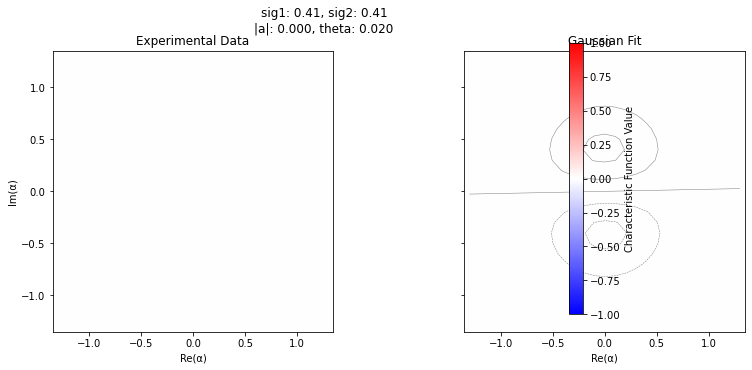

In [ ]:
# Create a figure with two panels
fig, (ax_orig, ax_fit) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# 1. Plot Original Data
im1 = ax_orig.pcolormesh(
    x_mesh,
    y_mesh,
    state,
    norm=colors.Normalize(vmin=-1, vmax=1),
    cmap="bwr",
    shading='auto' # Avoids the deprecation warning
)
ax_orig.set_title("Experimental Data")
ax_orig.set_aspect("equal")
ax_orig.set_xlabel("Re(α)")
ax_orig.set_ylabel("Im(α)")

# 2. Plot Fitted Data
im2 = ax_fit.pcolormesh(
    x_mesh,
    y_mesh,
    state_fit,
    norm=colors.Normalize(vmin=-1, vmax=1),
    cmap="bwr",
    shading='auto'
)
ax_fit.set_title("Gaussian Fit")
ax_fit.set_aspect("equal")
ax_fit.set_xlabel("Re(α)")

# Add contours to the fit - let Matplotlib choose levels automatically 
# to avoid "No contour levels found" warning
if np.max(np.abs(state_fit)) > 0:
    ax_fit.contour(x_mesh, y_mesh, state_fit, levels=5, colors='k', linewidths=0.5, alpha=0.5)

# Global formatting
fig.colorbar(im2, ax=[ax_orig, ax_fit], label='Characteristic Function Value')
fig.suptitle(label_txt)
plt.tight_layout()
plt.show()

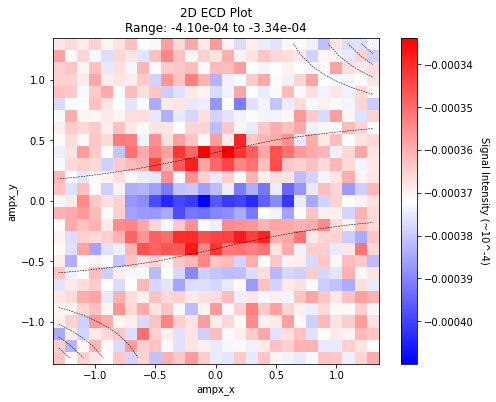

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

# Use the actual data range for color scaling
v_min, v_max = np.min(state), np.max(state)

fig, ax = plt.subplots(figsize=(8, 6))

# 1. Use 'shading=auto' and dynamic normalization
im = ax.pcolormesh(
    x, y, state, 
    shading='auto', 
    cmap='bwr', 
    norm=colors.Normalize(vmin=v_min, vmax=v_max)
)

# 2. Dynamic contours: let Matplotlib pick 5 levels within your 10^-4 range
CS = ax.contour(x_mesh, y_mesh, state_fit, levels=5, colors='k', linewidths=0.5)

ax.set_aspect("equal", "box")
ax.set_xlabel("ampx_x")
ax.set_ylabel("ampx_y")

# 3. Add a colorbar to see the actual values
cbar = fig.colorbar(im)
cbar.set_label('Signal Intensity (~10^-4)', rotation=270, labelpad=15)

plt.title(f"2D ECD Plot\nRange: {v_min:.2e} to {v_max:.2e}")
plt.show()

In [ ]:
print(x)

[-1.30000000e+00 -1.20000000e+00 -1.10000000e+00 -9.99999996e-01
 -8.99999995e-01 -7.99999993e-01 -6.99999992e-01 -5.99999990e-01
 -4.99999989e-01 -3.99999987e-01 -2.99999986e-01 -1.99999984e-01
 -9.99999829e-02  1.86264515e-08  1.00000020e-01  2.00000022e-01
  3.00000023e-01  4.00000025e-01  5.00000026e-01  6.00000028e-01
  7.00000029e-01  8.00000031e-01  9.00000032e-01  1.00000003e+00
  1.10000004e+00  1.20000004e+00  1.30000004e+00]


In [ ]:
print(y)

[-1.30000000e+00 -1.20000000e+00 -1.10000000e+00 -9.99999996e-01
 -8.99999995e-01 -7.99999993e-01 -6.99999992e-01 -5.99999990e-01
 -4.99999989e-01 -3.99999987e-01 -2.99999986e-01 -1.99999984e-01
 -9.99999829e-02  1.86264515e-08  1.00000020e-01  2.00000022e-01
  3.00000023e-01  4.00000025e-01  5.00000026e-01  6.00000028e-01
  7.00000029e-01  8.00000031e-01  9.00000032e-01  1.00000003e+00
  1.10000004e+00  1.20000004e+00  1.30000004e+00]


In [ ]:
state

array([[-0.00036933, -0.00036667, -0.00036858, -0.00037204, -0.00036509,
        -0.00037677, -0.00037197, -0.00037058, -0.0003665 , -0.00036988,
        -0.00038163, -0.00036415, -0.00036913, -0.00035398, -0.00036461,
        -0.00036181, -0.00035954, -0.00037436, -0.0003642 , -0.00037518,
        -0.00036563, -0.00036886, -0.00036619, -0.00036505, -0.00036313,
        -0.00037439, -0.00036193],
       [-0.00036756, -0.0003666 , -0.00036785, -0.00036384, -0.00036369,
        -0.00037608, -0.00036323, -0.00036605, -0.00036793, -0.00036584,
        -0.00037133, -0.00038294, -0.0003637 , -0.00036698, -0.00036882,
        -0.00036579, -0.00036947, -0.00035716, -0.00036889, -0.00035979,
        -0.00036384, -0.00037159, -0.00037952, -0.00036097, -0.00036433,
        -0.00037101, -0.00036645],
       [-0.00036624, -0.00036571, -0.00036556, -0.00036188, -0.00036363,
        -0.00036085, -0.00037266, -0.00037277, -0.0003624 , -0.00037766,
        -0.00036659, -0.00037123, -0.00037645, -0.0003